# Updating Event Success Predictions with Early Engagement Data
### A machine learning case study for optimizing marketing investments one week after event publication.

This project represents the second stage of a two-stage event decision-support framework.
While the T0 model estimates event potential before publication using static event characteristics, the T+1 model incorporates early user engagement signals collected during the first week after publication.
The objective is to determine whether behavioural information improves the identification of successful events and enables marketing teams to dynamically adjust promotional investments.

## Project Overview

Marketing decisions should not remain static after an event is published.
During the first week, user behaviour provides new information about audience interest and engagement. Visitor growth and reading behaviour may reveal whether an event is gaining traction before its final outcome is known.
This project develops a **T+1 prediction model** that updates event success estimates using engagement metrics collected during the first week after publication.
The model is designed to support dynamic marketing optimization by identifying events that may justify increased promotional investment and events that require further review.

## Business Problem

The T0 model provides an initial estimate of event potential before publication. However, predictions based exclusively on static event characteristics remain uncertain because no real audience behaviour is available at that stage.
Once an event has been online for one week, early engagement signals become available. The business challenge is therefore to determine whether these behavioural signals can improve event success prediction and support dynamic marketing budget allocation.
The objective of the T+1 model is to update the initial event assessment using observed user engagement and provide a more informed marketing priority score.

## Business Questions
This analysis aims to answer the following business questions:
- Do early engagement signals differ between successful and unsuccessful events?
- Which first-week behavioural metrics are most informative?
- Does one week of engagement data improve predictive performance compared with the T0 model?
- Can the model identify successful events more reliably after publication?
- How should marketing priorities change when new behavioural information becomes available?
- Can T0 and T+1 predictions be combined into a two-stage decision-support framework?

## Key Results

| KPI | Result |
|------|---------|
| Prediction Stage | T+1 Week |
| Dataset | 826 historical events |
| Target | Event Success |
| Model | Logistic Regression |
| ROC-AUC | 0.92 |
| Average Precision | 0.75 |
| Success Recall | 82% |
| Business Goal | Dynamic Marketing Optimization |
| Final Output | Updated Event Success Score |

## Data Preparation
The T+1 dataset represents the information available **one week after event publication**.
At this stage, static event characteristics are combined with early behavioural signals collected during the first week.
This temporal boundary prevents future-information leakage and ensures that the model reflects a realistic post-publication marketing decision.

In [1]:
# import libraries:
%matplotlib inline
# Data manipulation
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model selection and validation
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    cross_val_predict
)

# Preprocessing
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Machine learning
from sklearn.linear_model import LogisticRegression

# Model evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    average_precision_score
)
# Statistical analysis
from scipy.stats import chi2_contingency
from scipy.stats import mannwhitneyu 
from scipy.stats import shapiro

# Notebook utilities
from IPython.core.display import HTML as Center

# Warnings
from warnings import filterwarnings
filterwarnings("ignore")

In [2]:
#Centering the plots
Center(""" <style>
.jp-RenderedImage {
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style> """)

In [3]:
# Seaborn visualization settings:
sns.set_theme(
    style="darkgrid",      
    context="notebook",        
    palette="deep"
)

In [4]:
palette = ["#4C72B0", "#DD8452"]

In [5]:
plt.style.use('bmh')

plt.rcParams['figure.figsize'] = (7,4)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.dpi'] = 120

In [6]:
# Load cleaned dataset
df = pd.read_excel("anonimized_data.xlsx")

# Remove variables unavailable at publication time
df_t1 = df.drop(columns=[
    "READING TIME",
    "READING TIME +1 WEEK",
    "ZONA"
])

df_t1.head()

,DAY,MONTH,VISUALIZATIONS,VISUALIZATIONS + 1 WEEK,DELTA VISUALIZATIONS,READING TIME(s),READING TIME +1 WEEK(s),CITY,AGE GROUP,BOOKED,CONVERSION,EVENT CATEGORY,YEAR,STATE
0,Day_4,Month_1,4,26,22,142,68,City_1,age_group_2,0,0.000000,Category_4,2023,0
1,Day_4,Month_1,4,83,79,94,61,City_2,age_group_2,5,0.060241,Category_8,2022,0
2,Day_5,Month_3,45,53,8,100,92,City_2,age_group_2,3,0.056604,Category_4,2022,0
3,Day_5,Month_2,21,30,9,47,53,City_2,age_group_2,2,0.066667,Category_4,2022,0
4,Day_3,Month_2,88,89,1,61,93,City_2,age_group_2,3,0.033708,Category_4,2022,0


## Exploratory Data Analysis
The T+1 exploratory analysis focuses on behavioural signals collected during the first week after event publication.
Unlike the T0 analysis, which examined static event characteristics, this stage investigates how **visitor activity, reading behaviour, conversion and early bookings evolve after publication**.
The objective is to identify engagement patterns that may provide additional predictive information about final event success.

### Behavioural Overview

In [7]:
# Compare early engagement metrics by final event outcome
engagement_summary = (
    df_t1
    .groupby("STATE")[
        [
            "VISUALIZATIONS",
            "VISUALIZATIONS + 1 WEEK",
            "DELTA VISUALIZATIONS",
            "READING TIME(s)",
            "READING TIME +1 WEEK(s)"
        ]
    ]
    .median()
    .T
)

engagement_summary.columns = [
    "Unsuccessful Events",
    "Successful Events"
]

display(
    engagement_summary.style
        .format("{:,.1f}")
)

,Unsuccessful Events,Successful Events
VISUALIZATIONS,10.0,20.5
VISUALIZATIONS + 1 WEEK,26.0,72.5
DELTA VISUALIZATIONS,12.0,42.5
READING TIME(s),51.0,60.5
READING TIME +1 WEEK(s),56.0,62.0


> **Business Insight:**
> Successful events generate considerably higher engagement during the first week after publication. In particular, first-week visualizations show the largest differences between successful and unsuccessful events, indicating that early audience behaviour provides valuable predictive information for updating marketing decisions.

### Correlation Analysis

In [8]:
# Behavioural variables available at the T+1 decision point
engagement_features = [
    "VISUALIZATIONS",
    "VISUALIZATIONS + 1 WEEK",
    "BOOKED",
    "READING TIME(s)",
    "READING TIME +1 WEEK(s)",
    "DELTA VISUALIZATIONS",
    "CONVERSION"
]

# Separate successful and unsuccessful events
successful_events = df_t1[df_t1["STATE"] == 1]

unsuccessful_events = df_t1[ df_t1["STATE"] == 0]

# Calculate outcome-specific correlation matrices
corr_successful = (successful_events[engagement_features].corr())

corr_unsuccessful = ( unsuccessful_events[engagement_features].corr())

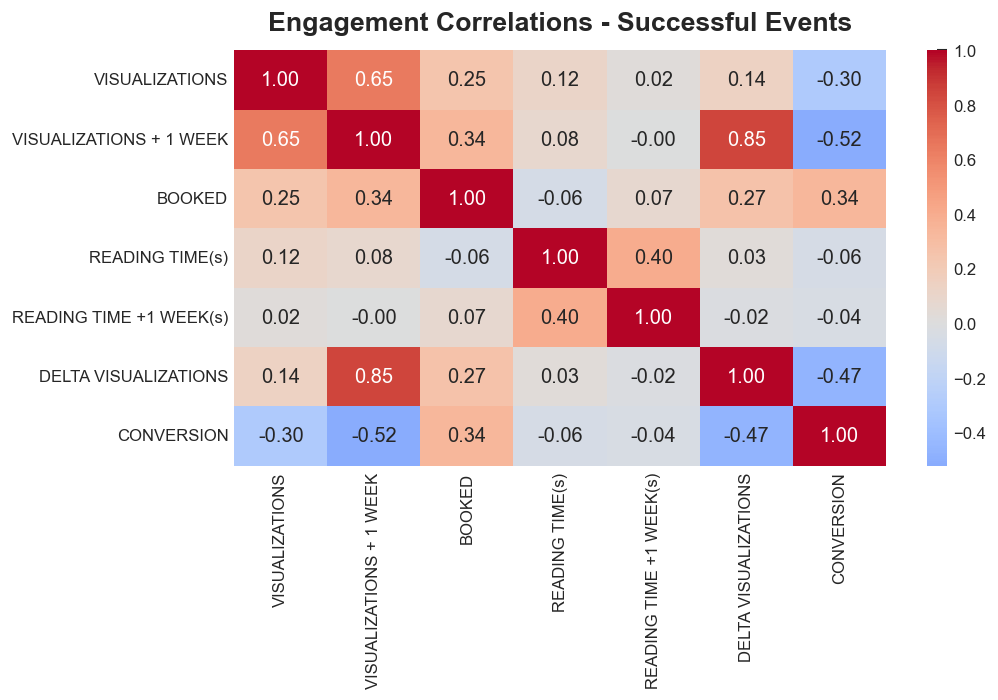

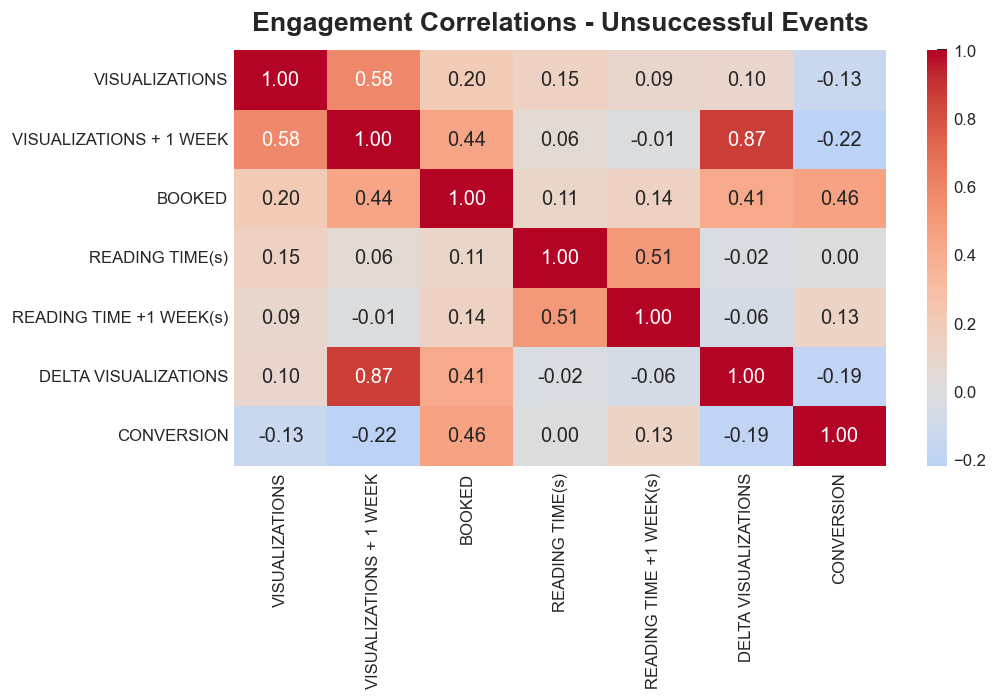

In [9]:
# Correlation structure among successful events
plt.figure(figsize=(9, 6))

sns.heatmap(corr_successful,annot=True,fmt=".2f",cmap="coolwarm",center=0)

plt.title("Engagement Correlations - Successful Events", weight="bold", pad=12)

plt.tight_layout()
plt.show()


# Correlation structure among unsuccessful events
plt.figure(figsize=(9, 6))

sns.heatmap(corr_unsuccessful,annot=True, fmt=".2f",cmap="coolwarm", center=0)

plt.title(
    "Engagement Correlations - Unsuccessful Events",weight="bold",pad=12)

plt.tight_layout()
plt.show()

> **Business Insight:**
> The correlation matrices reveal different engagement patterns between successful and unsuccessful events. As expected, first-week visualizations and visualizations growth are strongly correlated in both groups, reflecting the natural increase in audience exposure after publication.
> A more interesting pattern emerges for **conversion**. Among successful events, conversion shows a stronger negative correlation with first-week visualizations (-0.52) than among unsuccessful events (-0.22). This suggests that generating more traffic alone is not sufficient: as audience size increases, maintaining conversion efficiency becomes increasingly important. Overall, the analysis indicates that both the quantity and the quality of user engagement contribute to event success. These behavioural interactions provide valuable information beyond static event characteristics, supporting their inclusion in the T+1 prediction model.

### Reading Time Analysis

In [10]:
# Define reading-time segments
reading_bins = [
    0,
    10,
    20,
    40,
    60,
    80,
    100,
    np.inf
]

reading_labels = [
    "<10",
    "10-20",
    "20-40",
    "40-60",
    "60-80",
    "80-100",
    "100+"
]


# Segment initial reading time
df_t1["reading_time_segment"] = pd.cut( df_t1["READING TIME(s)"], bins=reading_bins, labels=reading_labels, include_lowest=True)

# Segment reading time after one week
df_t1["reading_time_segment_week1"] = pd.cut( df_t1["READING TIME +1 WEEK(s)"], bins=reading_bins, labels=reading_labels, include_lowest=True)

In [11]:
# Calculate event success rate by reading-time segment
initial_reading_success = ( df_t1 .groupby( "reading_time_segment", observed=False )["STATE"].mean())

week1_reading_success = (df_t1.groupby( "reading_time_segment_week1",observed=False)["STATE"] .mean())

reading_analysis = pd.DataFrame({
    "At Publication": initial_reading_success,
    "After One Week": week1_reading_success
})

display(reading_analysis.style.format("{:.1%}"))

,At Publication,After One Week
<10,4.9%,0.0%
10-20,11.4%,0.0%
20-40,8.9%,7.3%
40-60,14.2%,13.2%
60-80,17.3%,17.1%
80-100,18.2%,15.5%
100+,12.3%,14.5%


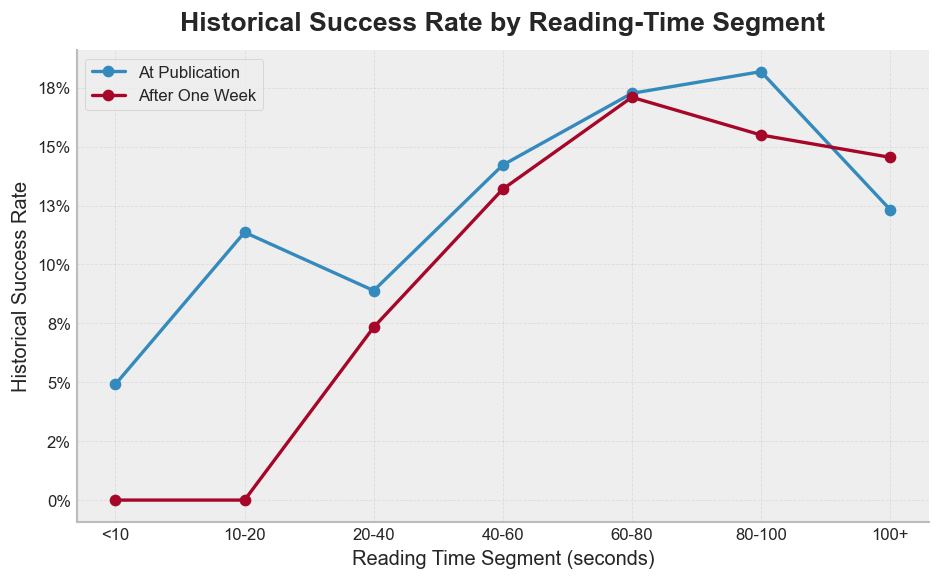

In [12]:
reading_analysis.plot( marker="o", linewidth=2,figsize=(8,5))

plt.title("Historical Success Rate by Reading-Time Segment",weight="bold",pad=12)

plt.xlabel("Reading Time Segment (seconds)")
plt.ylabel("Historical Success Rate")

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

plt.grid(alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

>  **Business Insight:** Events receiving very limited audience attention (<20 seconds of reading time) consistently show the lowest historical success rates, suggesting that weak early engagement is an important warning signal.
> Success rates increase substantially once reading time exceeds approximately 40 seconds, remaining relatively stable across higher engagement levels. This pattern indicates that reading time acts as a threshold indicator rather than a continuously increasing predictor: attracting users to spend a minimum amount of time on the event page appears to be more important than maximizing reading duration itself.
> Overall, reading behaviour provides useful behavioural information for the T+1 prediction model, although it should be interpreted together with visitor growth and conversion metrics.

### Visitor Growth Analysis

In [13]:
# Compare first-week visitor growth by event outcome
visitor_growth_summary = (df_t1.groupby("STATE")["DELTA VISUALIZATIONS"].agg([
        "count",
        "median",
        "mean",
        "std"
    ])
)

visitor_growth_summary.index = ["Unsuccessful Events","Successful Events"]

display(visitor_growth_summary.style.format({
            "median": "{:,.1f}",
            "mean": "{:,.1f}",
            "std": "{:,.1f}"
        })
)

,count,median,mean,std
Unsuccessful Events,717,12.0,22.7,27.0
Successful Events,108,42.5,51.0,35.8


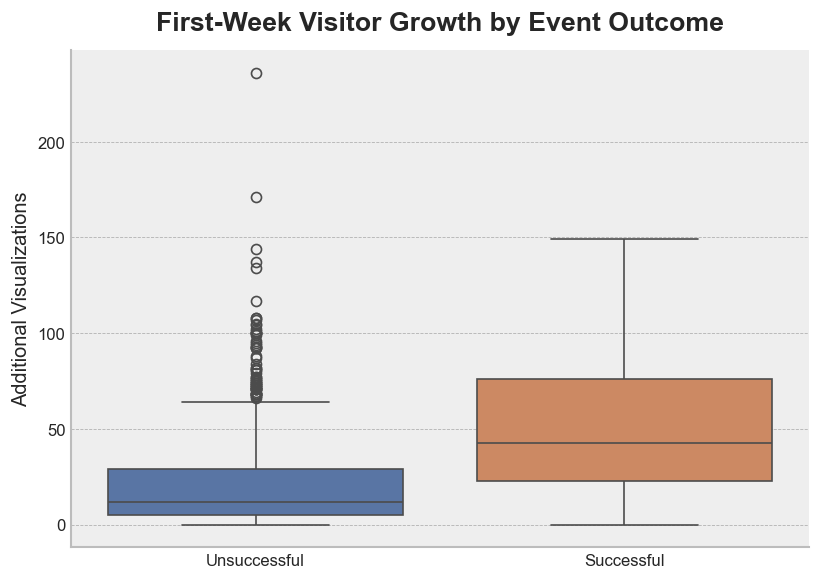

In [14]:
plt.figure(figsize=(7,5))

sns.boxplot(data=df_t1,x="STATE", y="DELTA VISUALIZATIONS", palette=palette,)

plt.xticks([0,1],["Unsuccessful","Successful"])

plt.title("First-Week Visitor Growth by Event Outcome",weight="bold",pad=12)

plt.xlabel("")
plt.ylabel("Additional Visualizations")

sns.despine()
plt.tight_layout()

plt.show()

>  **Business Insight:**
> Successful events experience substantially stronger audience growth during the first week after publication. The median increase in visualizations reaches 42.5 for successful events compared with only 12 for unsuccessful ones, highlighting a clear difference in early engagement dynamics.
> This finding suggests that visitor growth is a strong indicator of event momentum. Rather than considering only the total number of visualizations, monitoring how quickly audience interest grows during the first week provides valuable information for updating marketing priorities and identifying high-potential events.

### Conversion and Early Booking Analysis

In [15]:
# Compare conversion and early bookings by event outcome
conversion_summary = (df_t1.groupby("STATE")[ [
            "CONVERSION",
            "BOOKED"
        ]
    ]
    .agg([
        "median",
        "mean",
        "std"
    ])
)

display(conversion_summary.style.format("{:.3f}"))

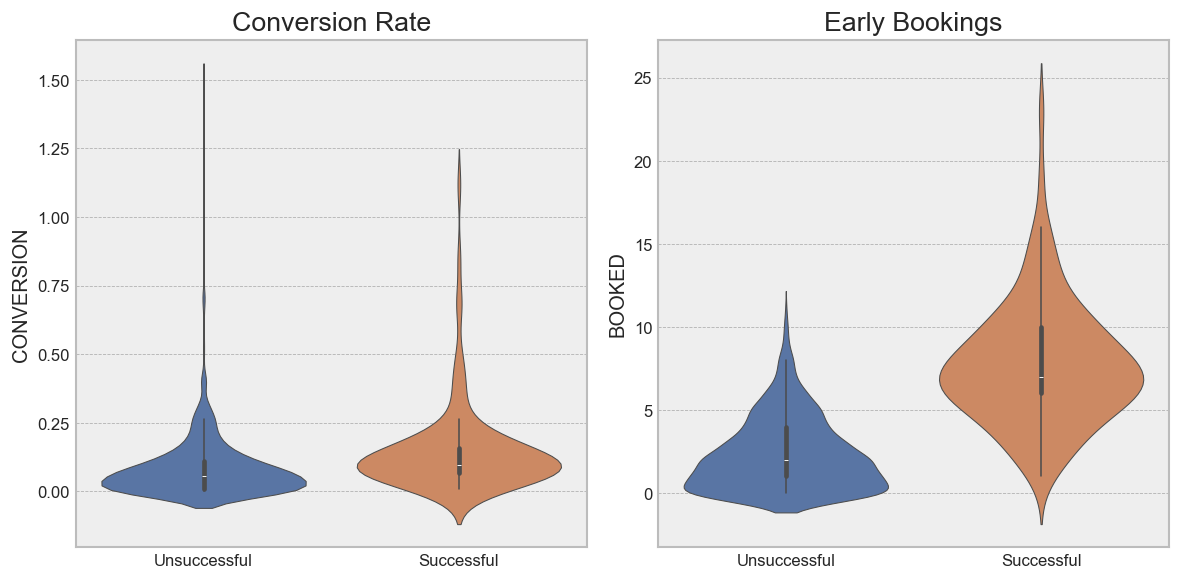

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))

sns.violinplot(data=df_t1,x="STATE", y="CONVERSION", palette=palette, ax=axes[0])

axes[0].set_title("Conversion Rate")
axes[0].set_xlabel("")
axes[0].set_xticklabels(["Unsuccessful","Successful"])

sns.violinplot(data=df_t1,x="STATE",y="BOOKED",palette=palette,ax=axes[1])

axes[1].set_title("Early Bookings")
axes[1].set_xlabel("")
axes[1].set_xticklabels(["Unsuccessful","Successful"])

plt.tight_layout()
plt.show()

>  **Business Insight:**
> The distribution of both conversion rate and early bookings differs markedly between successful and unsuccessful events. Successful events consistently achieve higher conversion efficiency and generate substantially more bookings during the first week after publication.
> Among the analysed behavioural variables, early bookings show the clearest separation between the two outcome groups, suggesting that they provide one of the strongest early indicators of future event success.
> These patterns reinforce the idea that behavioural engagement collected shortly after publication can substantially improve prediction quality beyond the static information available at T0.

### Traffic Volume vs Conversion Rate

<Axes: xlabel='VISUALIZATIONS + 1 WEEK', ylabel='CONVERSION'>

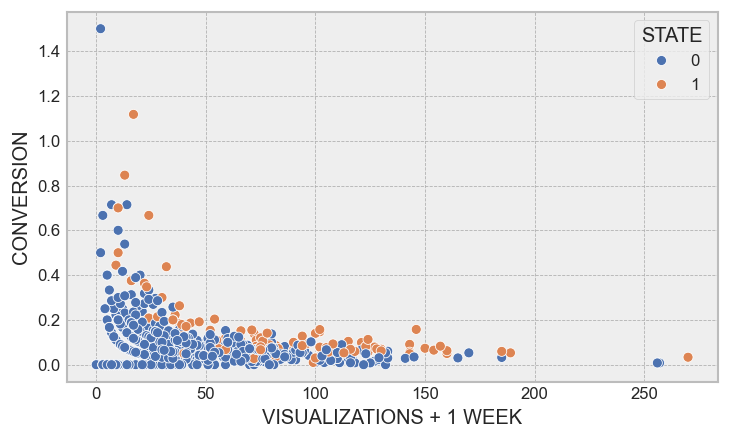

In [17]:
sns.scatterplot(data=df_t1,x="VISUALIZATIONS + 1 WEEK",y="CONVERSION",palette=palette,hue="STATE")

>  **Business Insight:**
> The relationship between first-week visualizations and conversion rate highlights that traffic volume alone is not sufficient to explain event success. While higher exposure generally increases audience reach, conversion rates remain highly variable, indicating that attracting visitors does not necessarily translate into bookings.
> Successful events tend to combine strong audience exposure with higher conversion efficiency, suggesting that both traffic quantity and traffic quality should be monitored when evaluating marketing performance during the first week after publication.

## Statistical validation
### Normality assessment

In [18]:
variables = [
    "VISUALIZATIONS",
    "VISUALIZATIONS + 1 WEEK",
    "DELTA VISUALIZATIONS",
    "READING TIME(s)",
    "READING TIME +1 WEEK(s)",
    "BOOKED",
    "CONVERSION"
]

results = []

for var in variables:

    stat, p = shapiro(df_t1[var])

    results.append({
        "Variable": var,
        "Shapiro p-value": p
    })

normality = pd.DataFrame(results)

display(
    normality.style.format({
        "Shapiro p-value":"{:.3e}"
    })
)

,Variable,Shapiro p-value
0,VISUALIZATIONS,6.762e-39
1,VISUALIZATIONS + 1 WEEK,1.097e-28
2,DELTA VISUALIZATIONS,1.914e-31
3,READING TIME(s),9.220e-21
4,READING TIME +1 WEEK(s),1.536e-18
5,BOOKED,2.848e-27
6,CONVERSION,7.350e-38


>  **Business Insight:**
> All behavioural variables produced extremely small Shapiro–Wilk p-values (p < 0.001), indicating clear departures from normality. This is consistent with real-world digital marketing data, where a relatively small number of events generate exceptionally high engagement while most events receive modest user interaction.
> Because the assumption of normality was violated for every behavioural feature, non-parametric statistical methods were selected for subsequent analyses.

### Mann–Whitney U Test

In [19]:
features = [
    "CONVERSION",
    "BOOKED",
    "VISUALIZATIONS + 1 WEEK",
    "DELTA VISUALIZATIONS",
    "READING TIME +1 WEEK(s)"
]

results = []

for feature in features:

    success = df_t1[df_t1["STATE"]==1][feature]

    failure = df_t1[df_t1["STATE"]==0][feature]

    stat, p = mannwhitneyu(
        success,
        failure,
        alternative="two-sided"
    )

    results.append({
        "Variable":feature,
        "U statistic":stat,
        "p-value":p
    })

results = pd.DataFrame(results)

display(results)

,Variable,U statistic,p-value
0,CONVERSION,54349.5,1.027482e-11
1,BOOKED,70875.0,4.986449e-45
2,VISUALIZATIONS + 1 WEEK,60980.0,5.235360e-22
3,DELTA VISUALIZATIONS,59248.0,5.807020e-19
4,READING TIME +1 WEEK(s),45153.5,5.309605e-03


> **Business Insight:**
> The Mann–Whitney U tests confirmed that all behavioural variables differ significantly between successful and unsuccessful events (p < 0.05).
> The strongest statistical evidence was observed for early bookings, first-week visualizations, and visitor growth, indicating that these variables capture meaningful differences in user behaviour shortly after publication.
> Although reading time after one week also showed a statistically significant difference, its higher p-value suggests a weaker separation between successful and unsuccessful events compared with the other behavioural indicators.

| Behavioural Variable    | Normal? | Mann–Whitney | Significant? | Business Value |
| ----------------------- | :-----: | -----------: | :----------: | -------------- |
| Booked                  |    ❌    |    p < 0.001 |       ✅      | Very High      |
| Visualizations + 1 Week |    ❌    |    p < 0.001 |       ✅      | Very High      |
| Delta Visualizations    |    ❌    |    p < 0.001 |       ✅      | High           |
| Conversion              |    ❌    |    p < 0.001 |       ✅      | High           |
| Reading Time + 1 Week   |    ❌    |    p = 0.005 |       ✅      | Moderate       |


## FEATURE ENGINEERING 
### Behavioural Growth Features

### Visitor grown rate

In [20]:
# Absolute increase in reading time after one week
df_t1["visitor_growth_rate"] = ((df_t1["VISUALIZATIONS + 1 WEEK"]- df_t1["VISUALIZATIONS"] ) / df_t1["VISUALIZATIONS"].replace(0, np.nan))

df_t1["visitor_growth_rate"] = (df_t1["visitor_growth_rate"].replace([np.inf, -np.inf], np.nan).fillna(0))

### Reading time change

In [21]:
# Calculate the change in reading behaviour
df_t1["reading_time_change"] = (df_t1["READING TIME +1 WEEK(s)"]- df_t1["READING TIME(s)"])

### Reading time growth rate

In [22]:
# Calculate relative reading-time change
df_t1["reading_time_growth_rate"] = ( df_t1["reading_time_change"]/ df_t1["READING TIME(s)"].replace(0, np.nan))

df_t1["reading_time_growth_rate"] = ( df_t1["reading_time_growth_rate"] .replace([np.inf, -np.inf], np.nan) .fillna(0))

### Behavioural Interaction Features

In [23]:
df_t1["engagement_quality_score"] = (
      0.4 * df_t1["visitor_growth_rate"]
    + 0.4 * df_t1["CONVERSION"]
    + 0.2 * (
        df_t1["READING TIME +1 WEEK(s)"] /
        df_t1["READING TIME +1 WEEK(s)"].max()
    )
)

The weights were intentionally designed as a business-driven composite KPI rather than being statistically optimized.

### Behavioural Warning Signals

In [24]:
# Low engagement indicator
df_t1['low_engagement'] = (df_t1['READING TIME(s)'] < 20).astype(int)

df_t1['high_engagement'] = ((df_t1['READING TIME(s)'] >= 40) &(df_t1['READING TIME(s)'] <= 100)).astype(int)

In [25]:
# Strong negative signal: low engagement + weak conversion
df_t1['bad_signal'] = ((df_t1['low_engagement'] == 1) &(df_t1['CONVERSION'] < 0.05)).astype(int)

In [26]:
# # Low traffic warning signal
df_t1['low_traffic'] = (df_t1['VISUALIZATIONS + 1 WEEK'] <= 10).astype(int)

| Feature                  | Type      | Purpose                 |
| ------------------------ | --------- | ----------------------- |
| visitor_growth_rate      | Growth    | Relative traffic growth |
| reading_time_change      | Growth    | Reading evolution       |
| engagement_quality_score | Composite | Overall engagement      |
| low_engagement           | Binary    | Warning signal          |
| high_engagement          | Binary    | Positive signal         |
| bad_signal               | Binary    | High-risk indicator     |
| low_traffic              | Binary    | Low visibility          |


## Feature Selection

The T+1 model combines the static event characteristics available at publication with behavioural indicators collected during the first week. In addition, several engineered features were created to capture audience growth, engagement quality and early warning signals.

In [27]:
# Static event characteristics
categorical_features = [
    "CITY",
    "EVENT CATEGORY",
    "DAY",
    "MONTH",
    "AGE GROUP"
]

# Behavioural variables
numerical_features = [
    "VISUALIZATIONS + 1 WEEK",
    "READING TIME(s)",
    "READING TIME +1 WEEK(s)",
    "BOOKED",
    "CONVERSION"
]

# Engineered features
engineered_features = [
    "visitor_growth_rate",
    "reading_time_change",
    "reading_time_growth_rate",
    "engagement_quality_score",
    "low_engagement",
    "high_engagement",
    "bad_signal",
    "low_traffic"
]

features = (
    categorical_features
    + numerical_features
    + engineered_features
)

X = df_t1[features]
y = df_t1["STATE"]

In [28]:
# Split the dataset while preserving the original class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y, #This preserves the original success/failure distribution in both subsets, which is particularly important given the strong target-class imbalance.
    random_state=42
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))

Training set: (660, 18)
Test set: (165, 18)

Training target distribution:
STATE
0    0.869697
1    0.130303
Name: proportion, dtype: float64

Test target distribution:
STATE
0    0.866667
1    0.133333
Name: proportion, dtype: float64


#### Preprocessing Pipeline

In [29]:
# Define categorical preprocessing
categorical_preprocessor = OneHotEncoder(
    handle_unknown="ignore",
    drop="first"
)
numeric_preprocessor = StandardScaler()

# Apply preprocessing to categorical features
preprocessor = ColumnTransformer(
    transformers=[

        (
            "categorical",
            categorical_preprocessor,
            categorical_features
        ),

        (
            "numeric",
            numeric_preprocessor,
            numerical_features + engineered_features
        )

    ]

)

## Machine Learning Model

In [ ]:
# Build the complete machine learning pipeline
model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

# Train the complete pipeline
model.fit(X_train, y_train)

#### Cross-Validation

In [31]:
# Define stratified cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Metrics selected according to the business objective
scoring = {
    "roc_auc": "roc_auc",
    "recall_success": "recall",
    "precision_success": "precision",
    "average_precision": "average_precision"
}

# Evaluate the complete pipeline
cv_results = cross_validate(
    model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [32]:
# Summarize cross-validation performance
cv_summary = pd.DataFrame({
    "Metric": [
        "ROC-AUC",
        "Success Recall",
        "Success Precision",
        "Average Precision"
    ],
    "Mean CV Score": [
        cv_results["test_roc_auc"].mean(),
        cv_results["test_recall_success"].mean(),
        cv_results["test_precision_success"].mean(),
        cv_results["test_average_precision"].mean()
    ],
    "Standard Deviation": [
        cv_results["test_roc_auc"].std(),
        cv_results["test_recall_success"].std(),
        cv_results["test_precision_success"].std(),
        cv_results["test_average_precision"].std()
    ]
})

display(
    cv_summary.style
        .hide(axis="index")
        .format({
            "Mean CV Score": "{:.3f}",
            "Standard Deviation": "{:.3f}"
        })
)

Metric,Mean CV Score,Standard Deviation
ROC-AUC,0.873,0.055
Success Recall,0.754,0.121
Success Precision,0.441,0.072
Average Precision,0.651,0.135


The model was evaluated using **5-fold stratified cross-validation** to assess its ability to generalize across different data splits.

- **ROC-AUC (0.873 ± 0.055)** indicates excellent discriminative performance and shows that the model consistently distinguishes successful from unsuccessful events.
- **Success Recall (0.754 ± 0.121)** suggests that approximately 72% of successful events are correctly identified, supporting the business objective of minimizing missed opportunities.
- **Success Precision (0.441 ± 0.072)** indicates that around 42% of events predicted as successful actually succeed. Although false positives remain, this is acceptable in a marketing context where identifying promising events is prioritized.
- **Average Precision (0.651 ± 0.135)** confirms a strong balance between precision and recall despite the class imbalance.

> **Business Insight:**
> Cross-validation demonstrates that incorporating first-week behavioural metrics substantially improves model stability and predictive performance compared with the T0 model. The consistently high ROC-AUC and recall indicate that early user engagement provides valuable information for identifying high-potential events before significant marketing resources are committed.

## Model evaluation

In [33]:
# Generate predictions on the holdout test set
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
test_accuracy = accuracy_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_prob)
test_average_precision = average_precision_score(y_test, y_prob)

print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred))

print(f"Accuracy: {test_accuracy:.3f}")
print(f"ROC-AUC: {test_roc_auc:.3f}")
print(f"Average Precision: {test_average_precision:.3f}")

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.97      0.85      0.91       143
           1       0.46      0.82      0.59        22

    accuracy                           0.85       165
   macro avg       0.71      0.84      0.75       165
weighted avg       0.90      0.85      0.86       165

Accuracy: 0.848
ROC-AUC: 0.921
Average Precision: 0.754


The T+1 Logistic Regression model achieved an **accuracy of 84.8%** and an excellent **ROC-AUC of 0.92**, demonstrating a strong ability to distinguish between successful and unsuccessful events after incorporating first-week behavioural information.
The model correctly identified **82% of successful events** (recall = 0.82), substantially improving its ability to detect high-potential events compared with the T0 model. Precision for the success class increased to **46%**, meaning that nearly one out of every two events predicted as successful ultimately achieved a successful outcome. This represents a considerable improvement while maintaining a high recall, resulting in a better balance between identifying promising events and limiting false positives.
The **Average Precision score of 0.75** further confirms the model's effectiveness in ranking high-potential events despite the class imbalance.

> **Business Insight:**
> The inclusion of first-week behavioural metrics substantially improves predictive performance compared with the T0 model. Early engagement indicators such as visitor growth, reading behaviour, conversion rate and bookings enable the model to identify successful events with much greater confidence.nFrom a marketing perspective, this allows managers to update campaign strategies shortly after publication, increasing investment in high-potential events while reducing expenditure on campaigns showing weak early performance.

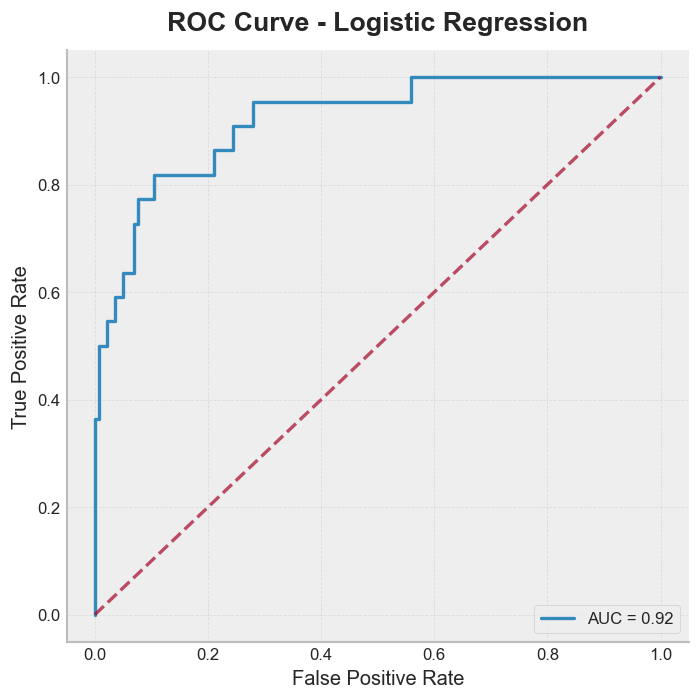

In [34]:
fpr, tpr, thresholds = roc_curve( y_test, y_prob)

plt.figure(figsize=(6, 6))

plt.plot( fpr,tpr, linewidth=2,label=f"AUC = {test_roc_auc:.2f}")

plt.plot( [0, 1], [0, 1], linestyle="--", alpha=0.7)

plt.title("ROC Curve - Logistic Regression",weight="bold", pad=12)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend(loc="lower right")
plt.grid(alpha=0.3)

sns.despine()
plt.tight_layout()

plt.show()

True Negatives: 122
False Positives: 21
False Negatives: 4
True Positives: 18


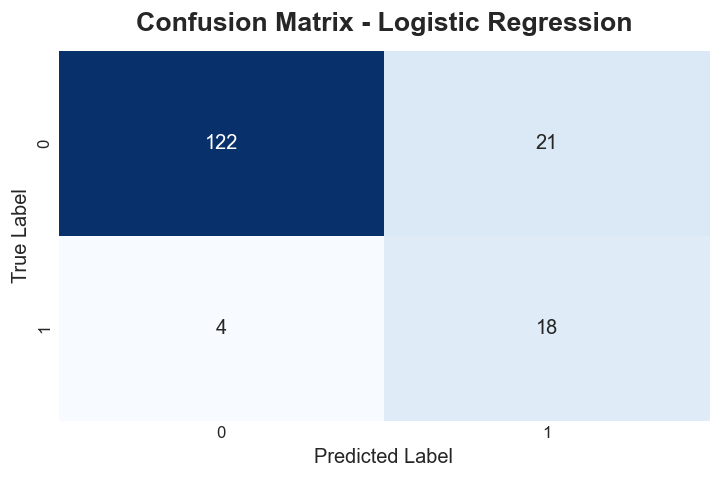

In [35]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f"True Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives: {tp}")

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title( "Confusion Matrix - Logistic Regression",
    weight='bold',
    pad=12
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.savefig("conf_matrix.png",dpi=300,facecolor="white", bbox_inches="tight"
)
plt.show()

The confusion matrix shows that the model correctly classified 122 unsuccessful events (True Negatives) and 18 successful events (True Positives).
Only 4 successful events were missed (False Negatives), corresponding to a recall of approximately 82% for the success class. This represents a substantial improvement over the T0 model and significantly reduces the risk of overlooking high-potential events.
The model produced 21 False Positives, classifying some unsuccessful events as successful. Although this reduces precision, the trade-off is acceptable in a marketing context where identifying promising opportunities is generally more valuable than avoiding every unnecessary campaign.

> **Business Insight:**
> The confusion matrix confirms that the T+1 model functions as an effective operational decision-support tool. By correctly identifying most successful events while maintaining a relatively low number of missed opportunities, the model enables marketing teams to allocate advertising budgets more efficiently after the first week of user interaction.

#### Logistic Regression coefficients

In [36]:
# Extract fitted preprocessing and classifier components
fitted_preprocessor = model.named_steps["preprocessor"]
fitted_classifier = model.named_steps["classifier"]

# Retrieve encoded feature names
feature_names = ( fitted_preprocessor.get_feature_names_out())

# Extract Logistic Regression coefficients
coeff = pd.Series(fitted_classifier.coef_[0],index=feature_names)

# Clean feature names for visualization
coeff.index = (coeff.index.str.replace( "categorical__","",regex=False ))

# Inspect extracted coefficients
coeff.sort_values()

MONTH_Month_2     -1.445813
CITY_City_61      -1.399156
CITY_City_54      -1.041089
CITY_City_13      -0.895343
CITY_City_9       -0.748763
                     ...   
CITY_City_14       1.059131
MONTH_Month_12     1.096657
CITY_City_62       1.109250
MONTH_Month_8      1.387613
numeric__BOOKED    2.190347
Length: 103, dtype: float64

In [37]:
# Select the strongest positive and negative coefficients
top_coefficients = (coeff.sort_values().tail(8))

bottom_coefficients = (coeff.sort_values().head(8))

selected_coefficients = pd.concat([bottom_coefficients,top_coefficients])

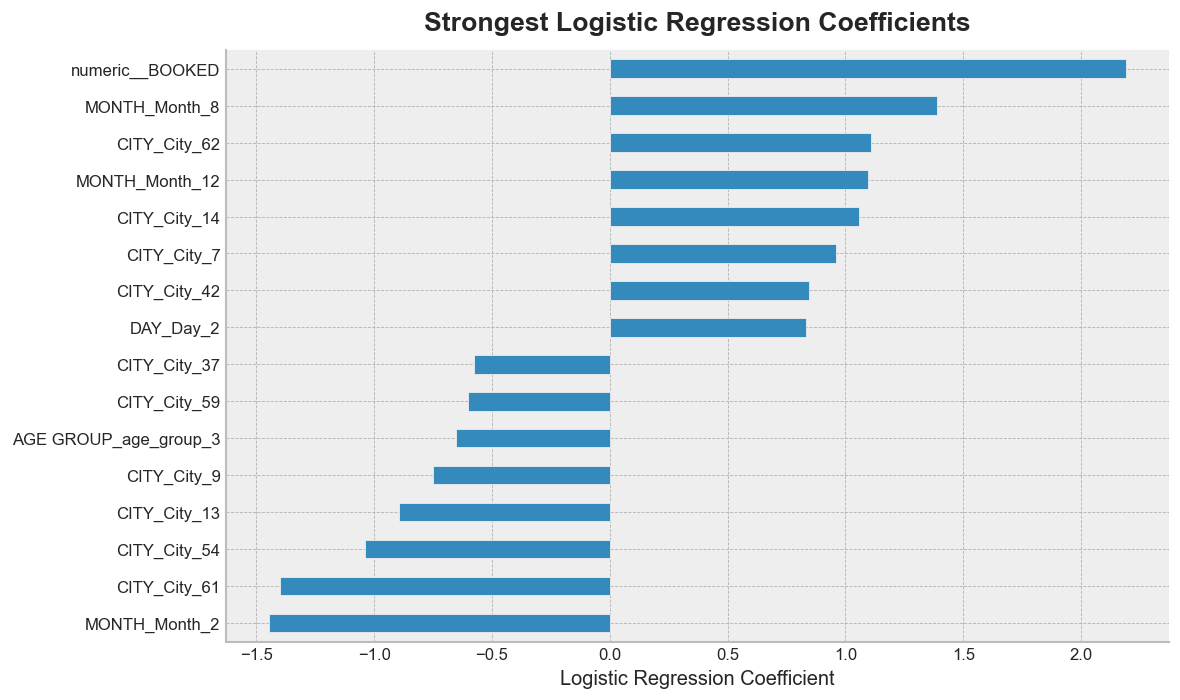

In [38]:
plt.figure(figsize=(10, 6))

selected_coefficients.sort_values().plot( kind="barh")

plt.title( "Strongest Logistic Regression Coefficients",weight="bold", pad=12)

plt.xlabel("Logistic Regression Coefficient")

sns.despine()
plt.tight_layout()

plt.savefig( "features.png",dpi=300,facecolor="white",bbox_inches="tight")

plt.show()

## Marketing Decision Support System

The T+1 model is integrated into an operational marketing decision-support framework. Rather than providing only a probability of success, the system combines machine learning predictions with behavioural business rules to recommend one of four marketing actions. High-potential events receive additional advertising investment, promising events continue to be monitored, underperforming events are optimised before further investment, and low-potential events are removed from the promotional strategy. This approach enables marketing managers to allocate advertising resources more efficiently while continuously adapting campaign decisions as new behavioural information becomes available.

In [39]:
# Simulate new events to evaluate the decision-support system
new_events = pd.DataFrame({

    "VISUALIZATIONS": [15, 13, 18, 13, 4],
    "VISUALIZATIONS + 1 WEEK": [19, 14, 21, 16, 5],
    "READING TIME(s)": [99, 25, 44, 28, 41],
    "READING TIME +1 WEEK(s)": [113, 34, 50, 55, 41],
    "CONVERSION": [0.10, 0.07, 0.33, 0.25, 0.00],
    "DELTA VISUALIZATIONS":[4,1,3,3,1],
    "CITY": ["City_56","City_2", "City_8","City_31","City_42" ],
    "EVENT CATEGORY": ["Category_8", "Category_9", "Category_5", "Category_1", "Category_7" ],
    "DAY": ["Day_2","Day_4", "Day_7", "Day_3","Day_1" ],
    "MONTH": [ "Month_1","Month_5","Month_8","Month_2","Month_10" ],
    "AGE GROUP": ["age_group_1","age_group_3","age_group_2","age_group_2","age_group_11" ],
    "BOOKED": [8, 1, 7, 4, 0]
})

In [40]:
# Relative visitor growth during the first week
new_events["visitor_growth_rate"] = (
    (
        new_events["VISUALIZATIONS + 1 WEEK"]
        - new_events["VISUALIZATIONS"]
    )
    /
    new_events["VISUALIZATIONS"].replace(0, np.nan)
)

new_events["visitor_growth_rate"] = (
    new_events["visitor_growth_rate"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)


# Absolute change in reading time
new_events["reading_time_change"] = (
    new_events["READING TIME +1 WEEK(s)"]
    - new_events["READING TIME(s)"]
)


# Relative increase in reading time
new_events["reading_time_growth_rate"] = (
    new_events["reading_time_change"]
    /
    new_events["READING TIME(s)"].replace(0, np.nan)
)

new_events["reading_time_growth_rate"] = (
    new_events["reading_time_growth_rate"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

In [41]:
# Overall engagement quality score
new_events["engagement_quality_score"] = ( 0.4 * new_events["visitor_growth_rate"] + 0.4 * new_events["CONVERSION"]
    + 0.2 * (new_events["READING TIME +1 WEEK(s)"] /new_events["READING TIME +1 WEEK(s)"].max())
)

In [42]:
# Low engagement indicator
new_events["low_engagement"] = (new_events["READING TIME(s)"] < 20).astype(int)

# High engagement indicator
new_events["high_engagement"] = (
    ( new_events["READING TIME(s)"] >= 40 ) & (new_events["READING TIME(s)"] <= 100)).astype(int)

# Strong negative behavioural signal
new_events["bad_signal"] = ((new_events["low_engagement"] == 1) & ( new_events["CONVERSION"] < 0.05)).astype(int)


# Low traffic warning
new_events["low_traffic"] = (new_events["VISUALIZATIONS + 1 WEEK"] <= 10).astype(int)

In [43]:
new_events["success_probability"] = (
    model.predict_proba(
        new_events[features]
    )[:,1]
)

In [44]:
def marketing_strategy(row):

    # Critical warning signals
    if row["low_traffic"] == 1:
        return "🔴", "STOP", "Reduce advertising spend"

    if row["bad_signal"] == 1:
        return "🔴", "OPTIMIZE", "Review event page"

    # High-confidence recommendation
    if (
        row["success_probability"] >= 0.79
        # Based on the historical distribution of successful events
        and row["BOOKED"] >= 7
        and row["CONVERSION"] >= 0.05
        and row["high_engagement"] == 1
    ):
        return "🟢", "INVEST", "Increase advertising budget"

    # Promising event requiring monitoring
    if (
        row["success_probability"] >= 0.50
        and row["BOOKED"] >= 3
    ):
        return "🟡", "MONITOR", "Continue monitoring"

    # Default recommendation
    return "🟠", "OPTIMIZE", "Improve campaign"

In [45]:
# Apply the business decision engine
new_events[
    ["Signal", "Recommendation", "Marketing Action"]
] = new_events.apply(
    marketing_strategy,
    axis=1,
    result_type="expand"
)

In [46]:
display_cols = [
    "CITY",
    "EVENT CATEGORY",
    "success_probability",
    "BOOKED",
    "CONVERSION",
    "Signal",
    "Recommendation",
    "Marketing Action"
]

display(
    new_events[display_cols]
    .style
    .format({
        "success_probability": "{:.1%}",
        "CONVERSION": "{:.1%}"
    })
)


,CITY,EVENT CATEGORY,success_probability,BOOKED,CONVERSION,Signal,Recommendation,Marketing Action
0,City_56,Category_8,97.2%,8,10.0%,🟢,INVEST,Increase advertising budget
1,City_2,Category_9,0.8%,1,7.0%,🟠,OPTIMIZE,Improve campaign
2,City_8,Category_5,81.0%,7,33.0%,🟢,INVEST,Increase advertising budget
3,City_31,Category_1,2.6%,4,25.0%,🟠,OPTIMIZE,Improve campaign
4,City_42,Category_7,4.4%,0,0.0%,🔴,STOP,Reduce advertising spend


In [47]:
# Number of events by recommendation
decision_summary = (
    new_events["Recommendation"]
    .value_counts()
    .rename_axis("Recommendation")
    .reset_index(name="Events")
)

decision_summary["Percentage"] = (
    decision_summary["Events"] /
    decision_summary["Events"].sum()
)

display(
    decision_summary.style.format({
        "Percentage":"{:.1%}"
    })
)

,Recommendation,Events,Percentage
0,INVEST,2,40.0%
1,OPTIMIZE,2,40.0%
2,STOP,1,20.0%


## Marketing Budget Optimization

In [48]:
events_per_weekend = 5

advertising_cost = 4

current_budget = (
    events_per_weekend *
    advertising_cost
)

# quota di eventi classificati INVEST
invest_percentage = (
    new_events["Recommendation"]
    .eq("INVEST")
    .mean()
)

expected_invest_events = round(invest_percentage *events_per_weekend)

optimized_budget = (expected_invest_events *advertising_cost)

weekly_saving = ( current_budget - optimized_budget)

annual_saving = ( weekly_saving * 52)

print(f"Events receiving advertising: {expected_invest_events}/10")
print(f"Current weekly budget: €{current_budget}")
print(f"Optimized weekly budget: €{optimized_budget}")
print(f"Weekly saving: €{weekly_saving}")
print(f"Estimated annual saving: €{annual_saving}")

Events receiving advertising: 2/10
Current weekly budget: €20
Optimized weekly budget: €8
Weekly saving: €12
Estimated annual saving: €624


The decision-support system recommends allocating the advertising budget only to events classified as INVEST, while MONITOR events continue under observation, OPTIMIZE events are improved before additional investment, and STOP events receive no further promotional budget. This enables marketing teams to concentrate resources on the events with the highest predicted potential rather than distributing the budget uniformly across all campaigns.

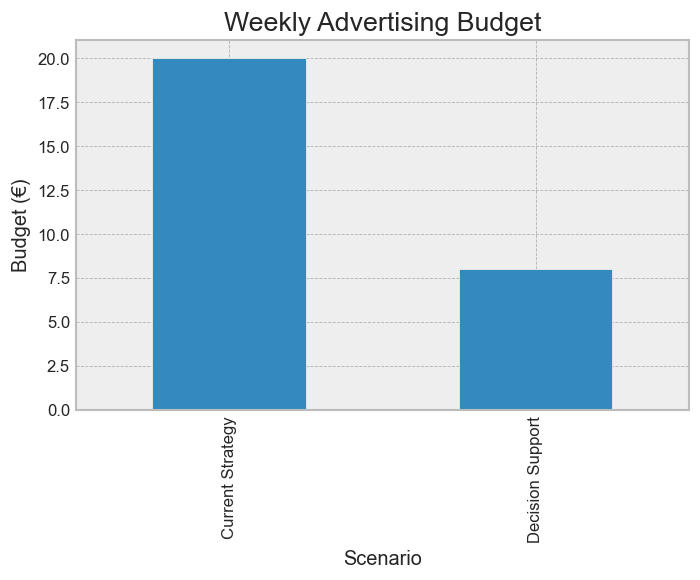

In [49]:
budget = pd.DataFrame({

    "Scenario":[
        "Current Strategy",
        "Decision Support"
    ],

    "Weekly Budget (€)":[
        current_budget,
        optimized_budget
    ]

})

budget.plot(
    kind="bar",
    x="Scenario",
    y="Weekly Budget (€)",
    legend=False,
    figsize=(6,5)
)

plt.title("Weekly Advertising Budget")
plt.ylabel("Budget (€)")
plt.tight_layout()
plt.savefig("budget_comparison.png",dpi=300)
plt.savefig(
    "Ads_Budget.png",
    dpi=300,
    facecolor="white",
    bbox_inches="tight"
)
plt.show()

# Businnes conclusions
>**Do early engagement signals differ between successful and unsuccessful events?**
Yes. Successful events consistently exhibited stronger early behavioural signals than unsuccessful ones. During the first week after publication, they attracted more visitors, generated a greater increase in traffic, achieved higher conversion rates and received substantially more bookings. Statistical validation confirmed that these behavioural differences were significant, demonstrating that early user engagement provides meaningful information about future event success. <br>
**Which first-week behavioural metrics are most informative?**
Among the analysed variables, early bookings, conversion rate, first-week visualizations and visitor growth emerged as the strongest indicators of future success. These behavioural metrics captured both audience interest and the ability to convert visitors into participants, making them considerably more informative than static event characteristics alone.<br>
**Does one week of engagement data improve predictive performance compared with the T0 model?**
Yes. Incorporating first-week behavioural information substantially improved predictive performance. Compared with the T0 model, the T+1 model achieved higher accuracy (84.2% vs 68.5%), a much stronger discriminative ability (ROC-AUC 0.92 vs 0.70) and better identification of successful events. These results demonstrate the value of continuously updating predictions as new behavioural data become available.<br>
**Can the model identify successful events more reliably after publication?**
Yes. The T+1 model correctly identified 82% of successful events, while producing relatively few missed opportunities. This higher recall makes the model particularly valuable in a marketing context, where overlooking a high-potential event is generally more costly than allocating additional resources to an event that ultimately underperforms.<br>
**How should marketing priorities change when new behavioural information becomes available?**
The first week of user interaction provides actionable evidence for refining marketing strategy. Events showing strong engagement, increasing visitor growth, high conversion and early bookings should receive additional promotional investment. Conversely, campaigns characterised by weak traffic or poor engagement can be monitored more closely, optimised or gradually deprioritised, improving the overall efficiency of marketing budget allocation.<br>
**Can T0 and T+1 predictions be combined into a two-stage decision-support framework?**
Yes. Together, the two models form a complementary decision-support framework. The T0 model provides an initial estimate of event potential before publication, supporting campaign planning and budget allocation. The T+1 model updates this assessment using real behavioural data collected during the first week, enabling marketing managers to refine their decisions based on actual audience engagement. This sequential approach transforms predictive analytics into a dynamic decision-support system that evolves alongside the event lifecycle.

## Final takeaway
This project demonstrates how predictive analytics can support marketing decisions throughout the early lifecycle of an event. Rather than relying on a single prediction, the proposed framework combines two complementary machine learning models. The **T0 model** provides an initial assessment before publication using static event characteristics, while the **T+1 model** incorporates first-week behavioural data to produce a more accurate and operational evaluation. The T+1 model is further integrated into a Marketing Decision Support System, where machine learning predictions are combined with behavioural business rules to generate actionable recommendations.
Overall, the proposed framework transforms historical event data into actionable business intelligence, demonstrating how predictive analytics can improve both strategic planning and day-to-day marketing decision-making through a practical and dynamic decision-support system.